# Gun Detection Training (YOLOv8 + MLflow)

This notebook handles the end-to-end process for Gun Detection:
1. **Data Preparation**: Merges Real and Synthetic datasets (V2/V3), splits them, and formats for YOLO.
2. **Training**: Fine-tunes a YOLOv8 model with MLflow tracking.
3. **Validation**: Evaluates the model on the test split.

Working Directory: d:\_pribadi\gun_detection
Running Data Preparation...
Project Root: D:\_pribadi\gun_detection

DATASET ANALYSIS (Graph Generation)
----------------------------------------------------------------------
[Visualization] Inventory plot saved to: D:\_pribadi\gun_detection\data\dataset_inventory_comparison.png

[Visualization] Split distribution plot saved to: D:\_pribadi\gun_detection\data\data_split_distribution.png


Processing test: 100%|██████████| 481/481 [00:01<00:00, 376.31it/s]


Created data_real.yaml
Created data_syn_v2.yaml
Created data_syn_v3.yaml
Created data_real_syn_v2.yaml
Created data_real_syn_v3.yaml
Created data_combined.yaml
Created data.yaml
Data preparation complete.


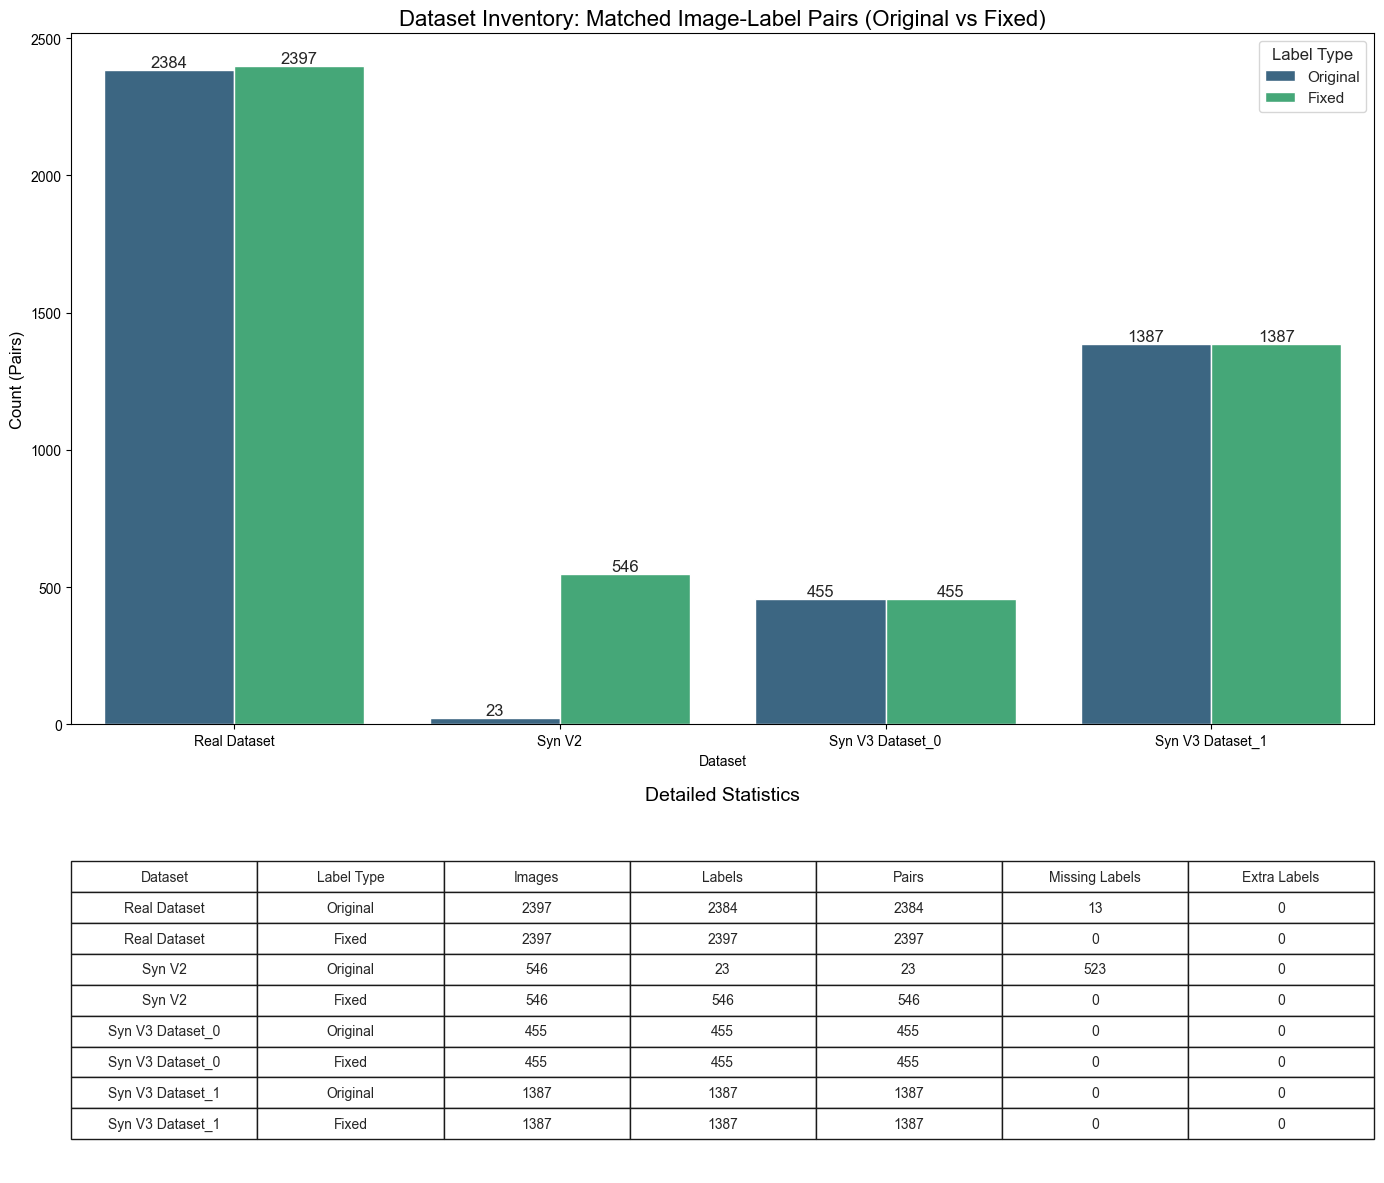

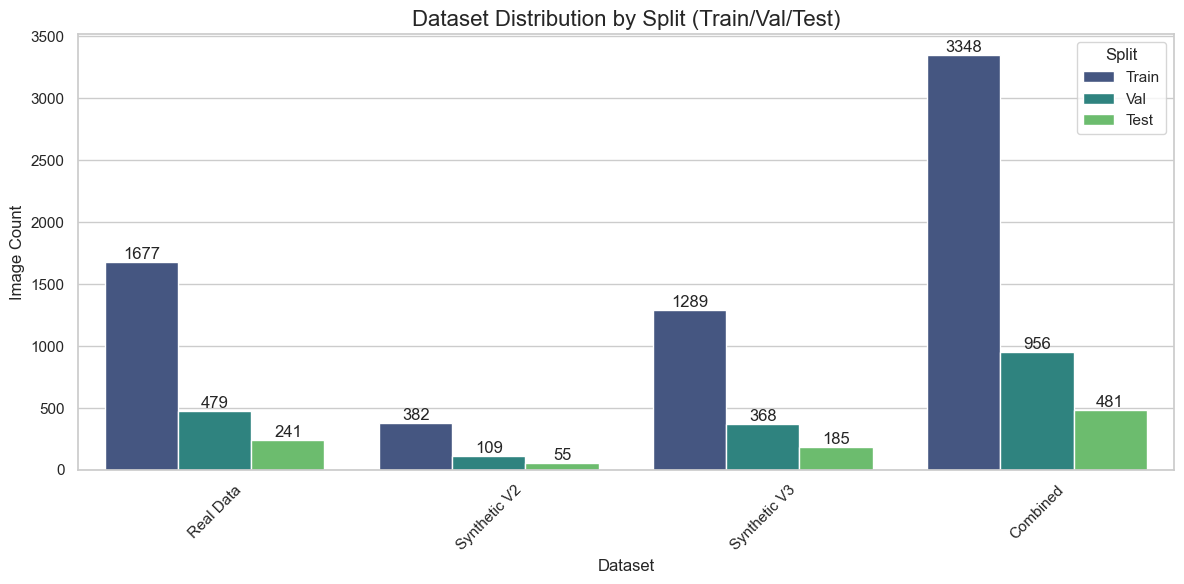

In [1]:
# --- 1. DATA PREPARATION ---
import sys
import os

# Ensure src/ is in python path
# Assumes notebook is in project root
notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.append(notebook_dir)

# Change working directory to project root
os.chdir(notebook_dir)
print(f"Working Directory: {os.getcwd()}")
from src.prepare_data import main as prepare_data

print("Running Data Preparation...")
# This will:
# 1. Gather files from Real, SynV2, and SynV3 datasets
# 2. Split them into Train/Val/Test (70/20/10)
# 3. Create 'data/images' and 'data/labels' structure
# 4. Generate 'data.yaml'
prepare_data()

In [ ]:
# --- 2. MODEL TRAINING ---
import os
import sys
import mlflow
import mlflow.pytorch
import mlflow.data
import torch
import pandas as pd
import sqlite3
import urllib.parse
from ultralytics import YOLO, settings

notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.append(notebook_dir)

# Configuration
# Use relative paths since we are in project_root
mlruns_dir = "mlruns" 
db_path = "mlflow.db"
tracking_uri = f"sqlite:///{db_path}"

model_name = "yolo26s.pt"  # Or 'yolov8n.pt', 'yolov8s.pt', etc.

# Select Dataset
dataset_names = ["real", "syn_v2", "syn_v3", "real_syn_v2", "real_syn_v3", "combined"]
selected_dataset = dataset_names[0] # Change index to select different dataset

# Data Config Path (Generated by prepare_data)
data_config = os.path.join("data", f"data_{selected_dataset}.yaml")
run_name = f"gun_detection_run_{selected_dataset}"

# MLflow Setup
mlflow.set_tracking_uri(tracking_uri)
os.environ["MLFLOW_TRACKING_URI"] = tracking_uri
os.environ["MLFLOW_EXPERIMENT_NAME"] = "Gun_Detection_Experiment"
settings.update({"mlflow": False}) # Disable default to use custom callback

print(f"Experiment: {os.environ['MLFLOW_EXPERIMENT_NAME']}")
print(f"Tracking URI: {tracking_uri}")

# Import Custom Callback
from src.mlflow_utils import MLflowYOLOCallback

# Initialize Callback with RUN NAME
mlflow_callback = MLflowYOLOCallback(
    run_name=run_name,
    experiment_name=os.environ["MLFLOW_EXPERIMENT_NAME"],
    tracking_uri=tracking_uri
)

# Patch SQLite logic to use relative paths for artifacts
def patch_sqlite_artifact_location():
    try:
        # Connect to DB to fix artifact location if it's absolute
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Check current artifact_location for the experiment
        exp_name = os.environ["MLFLOW_EXPERIMENT_NAME"]
        cursor.execute("SELECT experiment_id, artifact_location FROM experiments WHERE name=?", (exp_name,))
        row = cursor.fetchone()
        
        if row:
            exp_id, current_loc = row
            # Desired relative location: mlruns/EXP_ID (or just mlruns)
            # We explicitly want it to be 'mlruns'
            desired_loc = "mlruns"
            
            if not current_loc or current_loc.startswith("file:") or os.path.isabs(current_loc):
                print(f"Patching SQLite: Changing artifact_location from '{current_loc}' to '{desired_loc}'")
                cursor.execute("UPDATE experiments SET artifact_location=? WHERE experiment_id=?", (desired_loc, exp_id))
                conn.commit()
                print("SQLite patch successful.")
        else:
             # Experiment might not exist yet, MLflow will create it.
             pass
             
        conn.close()
    except Exception as e:
        print(f"Error patching SQLite: {e}")

# Ensure experiment exists
if not mlflow.get_experiment_by_name(os.environ["MLFLOW_EXPERIMENT_NAME"]):
    print("Creating experiment...")
    mlflow.create_experiment(os.environ["MLFLOW_EXPERIMENT_NAME"], artifact_location="mlruns")

# Run patch to ensure correctness (in case it existed with old absolute path)
patch_sqlite_artifact_location()

# Initialize Model
model = YOLO(model_name)

# Attach Callbacks
model.add_callback("on_pretrain_routine_start", mlflow_callback.on_pretrain_routine_start)
model.add_callback("on_train_epoch_end", mlflow_callback.on_train_epoch_end)
model.add_callback("on_train_end", mlflow_callback.on_train_end)

print(f"Training with config: {data_config}")

# --- Direct MLflow Output Setup ---
# The callback starts the run in 'on_pretrain_routine_start', but we need the artifact path now
# So we manually start/get the active run to determine the path before training starts
if not mlflow.active_run():
    mlflow.start_run(run_name=run_name)

active_run = mlflow.active_run()
if active_run:
    artifact_uri = active_run.info.artifact_uri
    print(f"MLflow Artifact URI: {artifact_uri}")
    
    # Convert file URI to local path
    artifact_path = urllib.parse.unquote(artifact_uri)
    if artifact_path.startswith("file:"):
        artifact_path = artifact_path.replace("file:///", "").replace("file:", "")
    
    # Handle Windows path absolute/relative correctly (remove leading slash if present on Windows)
    if os.name == 'nt' and artifact_path.startswith('/'):
        artifact_path = artifact_path[1:]
        
    # Force RELATIVE path from project root
    try:
        # Get absolute path first to be safe
        abs_artifact_path = os.path.abspath(artifact_path)

        # Ensure the directory exists immediately!
        os.makedirs(abs_artifact_path, exist_ok=True)
        print(f"Created/Verified artifact directory: {abs_artifact_path}")

        # Convert to relative path from CWD
        artifact_path = os.path.relpath(abs_artifact_path, os.getcwd())
    except ValueError:
        # Fallback if impossible (different drives), keep whatever we have
        pass

    print(f"YOLO Project (Artifact) Path: {artifact_path}")
    
    # Set YOLO project to this path
    # We use a fixed sub-folder name so it doesn't create nested runs/detect inside artifacts
    yolo_project = artifact_path
    yolo_name = "yolo_output" 
else:
    print("WARNING: No active MLflow run found. Fallback to default runs/detect.")
    yolo_project = "runs/detect"
    yolo_name = run_name

# Train
results = model.train(
    data=data_config,
    epochs=200,
    imgsz=640,
    batch=16,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=2,
    project=yolo_project,
    name=yolo_name,
    exist_ok=True,
    verbose=True
)

print("Training Complete. Artifacts and metrics logged via MLflowCallback.")


In [ ]:
# --- 3. VALIDATION ---
print("Validating on Test set...")
metrics = model.val(split='test')
print(f"mAP50-95: {metrics.box.map}")